In [ ]:
---
title: "Classification Models" 
---

# Packages

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score
from sklearn.metrics import classification_report

import numpy as np
import statsmodels.api as sm
from scipy import stats

# A.

In [ ]:
df = pd.read_csv('lobsterland_passholders_dataset_25.csv')

In [ ]:
df.head(5)

,Age,Previous_Visits,Total_Spend_2024,Feedback_Score,Gold_Zone_Visits,Email_Engagement_Score,Distance_From_Park_Miles,Home_State,Preferred_Attraction,Referral_Source,Dining_Plan,Renewed_Pass
0,59.000000,3.000000,394.780000,4.606232,4.000000,44.200000,1.900000,VT,Thrill,Social Media,Upgraded,0
1,27.846318,1.064843,172.541334,2.102264,2.000819,37.103840,21.709631,NH,Other,Ad/Other,NaN,1
2,18.000000,5.926144,151.731274,3.365074,1.019084,61.827722,21.892411,VT,Entertainment,Social Media,Upgraded,1
3,25.000000,12.000000,251.300000,3.458663,1.000000,41.800000,6.600000,NY,Other,Friend,Upgraded,0
4,66.206178,4.038141,197.686695,2.985864,3.955755,61.174332,29.981959,NJ,Entertainment,Ad/Other,Upgraded,1


# B.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1000 non-null   float64
 1   Previous_Visits           1000 non-null   float64
 2   Total_Spend_2024          1000 non-null   float64
 3   Feedback_Score            1000 non-null   float64
 4   Gold_Zone_Visits          1000 non-null   float64
 5   Email_Engagement_Score    1000 non-null   float64
 6   Distance_From_Park_Miles  1000 non-null   float64
 7   Home_State                1000 non-null   object 
 8   Preferred_Attraction      1000 non-null   object 
 9   Referral_Source           1000 non-null   object 
 10  Dining_Plan               667 non-null    object 
 11  Renewed_Pass              1000 non-null   int64  
dtypes: float64(7), int64(1), object(4)
memory usage: 93.9+ KB


Numerical: Age, Previous Visits, Total Spend, Feedback Score, Gold Zone Visits, Email Enagagement Score, Distance From Park Miles

Categorical: Home State, Preferred Action, Referral Source, Dinning Plan, Renewed Pass

# C.

In [ ]:
df['Renewed_Pass'].value_counts()

,count
Renewed_Pass,
1,580
0,420


The renewed pass shows whether or not the customer has renewed their season pass or not. There are 580 customers who did renew their pass and 420 customers who did not renew their pass.

In percentages terms, from the data given, 58% did renew and 42% did not renew

# D.

In [ ]:
df.isnull().sum()

,0
Age,0
Previous_Visits,0
Total_Spend_2024,0
Feedback_Score,0
Gold_Zone_Visits,0
Email_Engagement_Score,0
Distance_From_Park_Miles,0
Home_State,0
Preferred_Attraction,0
Referral_Source,0


The only variables with missing values is the Dinning Plan. It is missing 333 data points.

In [ ]:
df['Dining_Plan'].isnull().sum()

np.int64(333)

In [ ]:
df['Dining_Plan'].head(10)

,Dining_Plan
0,Upgraded
1,NaN
2,Upgraded
3,Upgraded
4,Upgraded
5,NaN
6,Upgraded
7,Upgraded
8,Upgraded
9,Upgraded


The definition for the variable Dining Plan shows that their should be two options - either None or Upgraded. The missing values are the values that have been left blank, when they should have been entered as 'No Upgrade'. Below I will convert the missing values (333) to say 'No Upgrade' to update and complete the data.

In [ ]:
df['Dining_Plan'] = df['Dining_Plan'].fillna('No Upgrade')
df['Dining_Plan'].value_counts()

,count
Dining_Plan,
Upgraded,667
No Upgrade,333


I chose this course of action as it was best to rename the missing values with a name to complete the data. This will make the data easier to handle when we run models later in the analysis. The data was supposed to be labeled as none, but was instead left blank, so completing them with the correct label is the best course of action.

In [ ]:
df['Dining_Plan'].isnull().sum()

np.int64(0)

# E.

In [ ]:
df.describe()

,Age,Previous_Visits,Total_Spend_2024,Feedback_Score,Gold_Zone_Visits,Email_Engagement_Score,Distance_From_Park_Miles,Renewed_Pass
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,45.843471,4.739685,211.420490,3.231483,2.045040,50.055373,30.708474,0.580000
std,16.278317,2.291030,105.815989,0.992790,1.411507,19.941021,17.108942,0.493805
min,18.000000,0.000000,-39.950000,1.000000,0.000000,-8.100000,0.100000,0.000000
25%,33.000000,3.000000,142.775364,2.585852,1.000000,35.975548,18.300000,0.000000
50%,46.278713,5.000000,199.942199,3.306673,2.000000,50.450000,29.837614,1.000000
75%,61.000000,6.005339,274.070000,3.826473,3.000000,62.783218,43.797075,1.000000
max,74.000000,12.000000,559.830000,5.000000,8.000000,108.300000,87.100000,1.000000


Impossible Values:

- Negative Minimum Spend


Having a minimum spend value of -$39 dollars is an impossible value as it is not possible for a customer to have a negative spend value. The best course of action is to adjust it with the average customer spend.

- Negative Email Engagement Score & Email Engagement Score above 100


Having both a negative engagement score and an engagement score that exceeds 100 are impossible values as the emailed engagement score is on a set scale between 0-100. The best course of action is to adjust these values with the average email enagement scores.


In [ ]:
negative_spend_values = df[df['Total_Spend_2024'] < 0]
display(negative_spend_values)

,Age,Previous_Visits,Total_Spend_2024,Feedback_Score,Gold_Zone_Visits,Email_Engagement_Score,Distance_From_Park_Miles,Home_State,Preferred_Attraction,Referral_Source,Dining_Plan,Renewed_Pass
228,34.632594,2.948977,-1.000297,3.072944,0.965401,53.158994,53.764673,ME,Other,Ad/Other,Upgraded,1
280,34.092198,2.986994,-0.508581,3.033482,0.977585,52.641486,53.059526,ME,Other,Ad/Other,Upgraded,0
465,54.000000,6.000000,-39.950000,3.142010,4.000000,58.900000,10.300000,NY,Other,Ad/Other,Upgraded,1
477,34.430205,2.951587,-0.751035,3.027981,0.996431,51.767003,52.981610,ME,Other,Ad/Other,Upgraded,1
485,33.764976,2.934015,-1.852003,3.043365,1.004973,53.342196,53.162699,ME,Other,Ad/Other,Upgraded,1
493,26.000000,5.000000,-2.230000,3.555003,2.000000,55.600000,27.800000,VT,Thrill,Ad/Other,Upgraded,1
499,33.327308,2.984666,-1.439116,3.037064,0.967710,53.574152,53.156368,ME,Other,Ad/Other,Upgraded,0
573,42.000000,4.000000,-23.910000,3.239964,6.000000,66.800000,32.500000,MA,Other,Social Media,Upgraded,1
750,33.715105,3.037335,-3.514091,3.059007,1.022880,53.124907,53.273690,ME,Other,Ad/Other,Upgraded,1
761,52.000000,4.000000,-3.180000,3.991413,4.000000,66.700000,51.200000,NJ,Entertainment,Ad/Other,Upgraded,0


In [ ]:
negative_email_engagement_values = df[df['Email_Engagement_Score'] < 0]
display(negative_email_engagement_values)

,Age,Previous_Visits,Total_Spend_2024,Feedback_Score,Gold_Zone_Visits,Email_Engagement_Score,Distance_From_Park_Miles,Home_State,Preferred_Attraction,Referral_Source,Dining_Plan,Renewed_Pass
379,21.0,4.0,345.79,2.868348,1.0,-8.1,39.3,ME,Thrill,Ad/Other,No Upgrade,0


In [ ]:
email_engagement_above_100 = df[df['Email_Engagement_Score'] > 100]
display(email_engagement_above_100)

,Age,Previous_Visits,Total_Spend_2024,Feedback_Score,Gold_Zone_Visits,Email_Engagement_Score,Distance_From_Park_Miles,Home_State,Preferred_Attraction,Referral_Source,Dining_Plan,Renewed_Pass
308,42.0,2.0,385.92,2.830563,1.0,102.9,9.4,MA,Other,Ad/Other,No Upgrade,0
418,37.0,4.0,339.49,3.264726,1.0,105.3,34.9,VT,Entertainment,Ad/Other,No Upgrade,1
902,55.0,4.0,150.17,4.445888,0.0,108.3,41.9,NY,Thrill,Ad/Other,Upgraded,0


In [ ]:

df = df[df['Total_Spend_2024'] >= 0]
df = df[(df['Email_Engagement_Score'] >= 0) & (df['Email_Engagement_Score'] <= 100)]

In [ ]:
df.describe()

,Age,Previous_Visits,Total_Spend_2024,Feedback_Score,Gold_Zone_Visits,Email_Engagement_Score,Distance_From_Park_Miles,Renewed_Pass
count,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000
mean,45.965625,4.757146,213.481205,3.231264,2.049862,49.876600,30.545799,0.579695
std,16.330602,2.300983,103.718096,0.998960,1.408377,19.751241,17.086689,0.493859
min,18.000000,0.000000,0.410760,1.000000,0.000000,0.000000,0.100000,0.000000
25%,33.000000,3.000000,144.815648,2.577811,1.000000,35.800000,18.300000,0.000000
50%,46.558002,5.000000,200.230000,3.309669,2.000000,49.871882,29.660018,1.000000
75%,61.000000,6.011676,274.310000,3.837766,3.000000,62.700000,43.100000,1.000000
max,74.000000,12.000000,559.830000,5.000000,8.000000,95.600000,87.100000,1.000000


I decided to entirely remove the rows with the impossible values as I could not accurately define the reason for the impossible values existing, meaning that there was a risk of warping the data through incorrect imputation or replacement methods. Since the size of the dataset is large enough and is still large enough to run a thorough analysis, it made the most sense to remove them entirely and not risk damaging the models/datas accuracy and integrity. Only 15 rows from 1,000 removed, meaning 1.5% were removed in cleaning.

# F.

In [ ]:
df.columns

Index(['Age', 'Previous_Visits', 'Total_Spend_2024', 'Feedback_Score',
       'Gold_Zone_Visits', 'Email_Engagement_Score',
       'Distance_From_Park_Miles', 'Home_State', 'Preferred_Attraction',
       'Referral_Source', 'Dining_Plan', 'Renewed_Pass'],
      dtype='object')

In [ ]:
df_numeric = df[['Age', 'Previous_Visits', 'Total_Spend_2024', 'Feedback_Score',
       'Gold_Zone_Visits', 'Email_Engagement_Score',
       'Distance_From_Park_Miles']]
correlation_matrix = df_numeric.corr()
correlation_matrix

,Age,Previous_Visits,Total_Spend_2024,Feedback_Score,Gold_Zone_Visits,Email_Engagement_Score,Distance_From_Park_Miles
Age,1.000000,0.072075,0.136470,0.007814,0.020522,-0.036572,0.099172
Previous_Visits,0.072075,1.000000,0.056477,-0.070618,-0.086343,-0.066925,-0.094986
Total_Spend_2024,0.136470,0.056477,1.000000,0.047996,-0.053313,-0.007239,0.067391
Feedback_Score,0.007814,-0.070618,0.047996,1.000000,0.029027,-0.095142,-0.034124
Gold_Zone_Visits,0.020522,-0.086343,-0.053313,0.029027,1.000000,0.030968,-0.092002
Email_Engagement_Score,-0.036572,-0.066925,-0.007239,-0.095142,0.030968,1.000000,-0.092865
Distance_From_Park_Miles,0.099172,-0.094986,0.067391,-0.034124,-0.092002,-0.092865,1.000000


Axes(0.125,0.11;0.62x0.77)


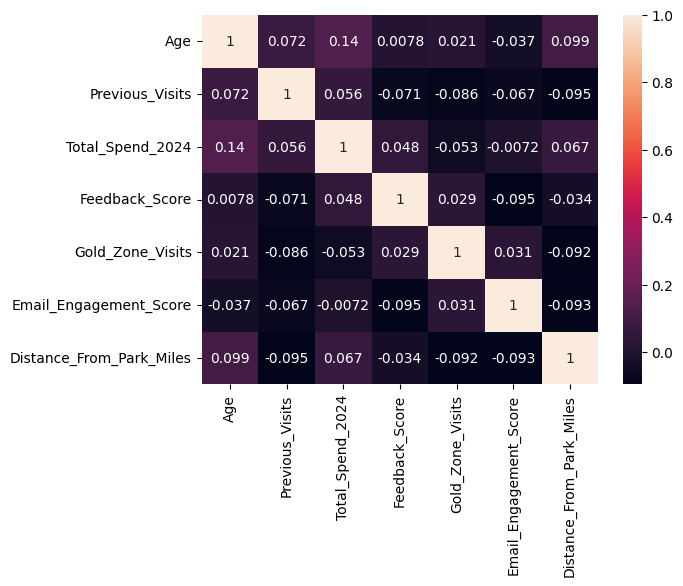

In [ ]:
correlation_map = sns.heatmap(correlation_matrix, annot=True)
print(correlation_map)

There are no correlations here that are high enough to present a likely problem with mutlicollinearity.

# G.

In [ ]:
df_dummies = pd.get_dummies(df,columns=['Home_State', 'Preferred_Attraction', 'Referral_Source', 'Dining_Plan'],drop_first=True)

In [ ]:
df_dummies = df_dummies.astype(int)

# H.

In [ ]:
df_dummies.columns

Index(['Age', 'Previous_Visits', 'Total_Spend_2024', 'Feedback_Score',
       'Gold_Zone_Visits', 'Email_Engagement_Score',
       'Distance_From_Park_Miles', 'Renewed_Pass', 'Home_State_ME',
       'Home_State_NH', 'Home_State_NJ', 'Home_State_NY', 'Home_State_VT',
       'Preferred_Attraction_Other', 'Preferred_Attraction_Thrill',
       'Referral_Source_Friend', 'Referral_Source_Social Media',
       'Dining_Plan_Upgraded'],
      dtype='object')

In [ ]:
X=df_dummies[['Age', 'Previous_Visits', 'Total_Spend_2024', 'Feedback_Score',
       'Gold_Zone_Visits', 'Email_Engagement_Score',
       'Distance_From_Park_Miles', 'Home_State_ME',
       'Home_State_NH', 'Home_State_NJ', 'Home_State_NY', 'Home_State_VT',
       'Preferred_Attraction_Other', 'Preferred_Attraction_Thrill',
       'Referral_Source_Friend', 'Referral_Source_Social Media',
       'Dining_Plan_Upgraded']]
y=df_dummies['Renewed_Pass']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=54)

In [ ]:
X_train.head()

,Age,Previous_Visits,Total_Spend_2024,Feedback_Score,Gold_Zone_Visits,Email_Engagement_Score,Distance_From_Park_Miles,Home_State_ME,Home_State_NH,Home_State_NJ,Home_State_NY,Home_State_VT,Preferred_Attraction_Other,Preferred_Attraction_Thrill,Referral_Source_Friend,Referral_Source_Social Media,Dining_Plan_Upgraded
697,38,0,196,3,1,43,23,0,0,0,1,0,1,0,0,0,0
36,70,6,336,5,4,57,36,0,0,0,0,1,0,1,0,0,0
826,53,3,207,2,2,55,10,0,0,0,1,0,1,0,0,0,1
834,49,4,290,2,3,60,25,0,1,0,0,0,1,0,1,0,1
797,29,3,150,1,3,64,11,0,0,0,0,1,0,0,0,0,1


I chose to use 54, which corresponds to my parents home address, where I grew up.

In [ ]:
print(X_train.shape, X_test.shape, type(X_train), type(X_test))
print(y_train.shape, y_test.shape, type(y_train), type(y_test))

(591, 17) (394, 17) <class 'pandas.core.frame.DataFrame'> <class 'pandas.core.frame.DataFrame'>
(591,) (394,) <class 'pandas.core.series.Series'> <class 'pandas.core.series.Series'>


# I.

In [ ]:
compare_means = df_dummies.groupby('Renewed_Pass').mean()
display(compare_means)

,Age,Previous_Visits,Total_Spend_2024,Feedback_Score,Gold_Zone_Visits,Email_Engagement_Score,Distance_From_Park_Miles,Home_State_ME,Home_State_NH,Home_State_NJ,Home_State_NY,Home_State_VT,Preferred_Attraction_Other,Preferred_Attraction_Thrill,Referral_Source_Friend,Referral_Source_Social Media,Dining_Plan_Upgraded
Renewed_Pass,,,,,,,,,,,,,,,,,
0,47.173913,4.492754,216.893720,2.724638,1.840580,50.768116,29.60628,0.111111,0.128019,0.166667,0.200483,0.292271,0.454106,0.347826,0.195652,0.212560,0.642512
1,44.746060,4.621716,210.136602,2.828371,1.863398,48.427320,30.41331,0.159370,0.173380,0.126095,0.178634,0.206655,0.478109,0.325744,0.145359,0.225919,0.681261


1. For the Total Spend in 2024, we can see that thoses who did not renew their pass their mean spending was slightly higher, by $6.7, than those who did renew their pass. I think this may have an impact on the result as it may reflect the visitors tendencies of spending more and their likelihood to visit again.

2.  For Previous Visits, we can see that those who did renew their pass attended lobsterland 0.13 more tahn those who did not renew their pass. I think this might have an impact on the result as it shows how much value a visitor may gain from having a pass versus paying for individual entries.

3. For Feedback Score, we can see that who did renew their pass, the feedback score was higher on average by 0.10 than those who did not renew their pass. I think this may have an impact on their views of lobsterland and how they enjoyed there time visiting. This may influence their likehold to return next season and buy another pass.



Email Engagement Score

# Iteration #1

# J.

In [ ]:
logit_model1 = sm.Logit(y_train, sm.add_constant(X_train))
iteration1 = logit_model1.fit()
print(iteration1.summary())

Optimization terminated successfully.
         Current function value: 0.650635
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           Renewed_Pass   No. Observations:                  591
Model:                          Logit   Df Residuals:                      573
Method:                           MLE   Df Model:                           17
Date:                Sun, 09 Nov 2025   Pseudo R-squ.:                 0.03758
Time:                        20:09:46   Log-Likelihood:                -384.53
converged:                       True   LL-Null:                       -399.54
Covariance Type:            nonrobust   LLR p-value:                   0.02612
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            0.7955      0.661      1.203      0.229

# K.

The **Numeric Variables** with high P-Values are Age, Total Spend 2024, Feedback Score, Gold Zone Visits, Email Engagement Score, Distance from park in Miles.


The **Categorical Variables** with high P-Values are Preferred Attraction and Dinning Plan.


**Keep** - Previous Visits, Home State, Referral Source


# Iteration #2

#L.

In [ ]:
x2_train = X_train[['Previous_Visits', 'Home_State_ME', 'Home_State_NH', 'Home_State_NJ', 'Home_State_NY', 'Home_State_VT', 'Referral_Source_Friend', 'Referral_Source_Social Media']]
x2_test = X_test[['Previous_Visits', 'Home_State_ME', 'Home_State_NH', 'Home_State_NJ', 'Home_State_NY', 'Home_State_VT', 'Referral_Source_Friend', 'Referral_Source_Social Media']]
y2_train = y_train
y2_test = y_test

In [ ]:
logit_model2 = sm.Logit(y_train, sm.add_constant(x2_train))
iteration2 = logit_model2.fit()
print(iteration2.summary())

Optimization terminated successfully.
         Current function value: 0.657363
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           Renewed_Pass   No. Observations:                  591
Model:                          Logit   Df Residuals:                      582
Method:                           MLE   Df Model:                            8
Date:                Sun, 09 Nov 2025   Pseudo R-squ.:                 0.02763
Time:                        20:09:46   Log-Likelihood:                -388.50
converged:                       True   LL-Null:                       -399.54
Covariance Type:            nonrobust   LLR p-value:                  0.004774
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            0.4613      0.324      1.422      0.155

# M.

In [ ]:
x3_train = X_train[['Previous_Visits', 'Home_State_ME', 'Home_State_NH', 'Home_State_NJ', 'Home_State_NY', 'Home_State_VT', 'Referral_Source_Friend', 'Referral_Source_Social Media']]
x3_test = X_test[['Previous_Visits', 'Home_State_ME', 'Home_State_NH', 'Home_State_NJ', 'Home_State_NY', 'Home_State_VT', 'Referral_Source_Friend', 'Referral_Source_Social Media']]
y3_train = y_train
y3_test = y_test

In [ ]:
logmodel3 = LogisticRegression(max_iter=1000, solver='lbfgs', class_weight = 'balanced')
logmodel3.fit(x3_train, y3_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y3_pred = logmodel3.predict(x3_test)

In [ ]:
coef_tbl = pd.DataFrame({
    "Variable": x3_train.columns,
    "Coef (log-odds)": logmodel3.coef_[0],
    "Odds Ratio": np.exp(logmodel3.coef_[0])
}).sort_values("Odds Ratio")
print(coef_tbl)
print("Intercept:", logmodel3.intercept_[0])

                       Variable  Coef (log-odds)  Odds Ratio
5                 Home_State_VT        -0.642933    0.525748
6        Referral_Source_Friend        -0.634257    0.530329
3                 Home_State_NJ        -0.583155    0.558135
4                 Home_State_NY        -0.219614    0.802829
2                 Home_State_NH        -0.044608    0.956372
1                 Home_State_ME         0.051775    1.053139
0               Previous_Visits         0.089092    1.093181
7  Referral_Source_Social Media         0.137917    1.147881
Intercept: -0.01590355779114381


# N.

In [ ]:
cm = confusion_matrix(y3_test, y3_pred)
TN, FP, FN, TP = cm.ravel()

In [ ]:
accuracy = accuracy_score(y3_test, y3_pred)
sensitivity = recall_score(y3_test, y3_pred)
specificity = TN / (TN + FP)
precision = precision_score(y3_test, y3_pred)
balanced_acc = balanced_accuracy_score(y3_test, y3_pred)

In [ ]:
print(f"Confusion Matrix:\n{cm}")

Confusion Matrix:
[[ 83  90]
 [ 84 137]]


In [ ]:
print("\nClassification report:\n", classification_report(y3_test, y3_pred, digits=3, zero_division=0))


Classification report:
               precision    recall  f1-score   support

           0      0.497     0.480     0.488       173
           1      0.604     0.620     0.612       221

    accuracy                          0.558       394
   macro avg      0.550     0.550     0.550       394
weighted avg      0.557     0.558     0.557       394



In [ ]:
print(f"Accuracy: {accuracy:.3f}")
print(f"Sensitivity (Recall): {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Balanced Accuracy: {balanced_acc:.3f}")


Accuracy: 0.558
Sensitivity (Recall): 0.620
Specificity: 0.480
Precision: 0.604
Balanced Accuracy: 0.550


# O.

In [ ]:
naive_rate = y3_test.value_counts(normalize=True).max()
print(f"Naive (Baseline) Accuracy Rate: {naive_rate:.3f}")

Naive (Baseline) Accuracy Rate: 0.561


The naive accuracy for this dataset is 56.1%, which represents the proportion of customers who renewed their passes. The models accuracy is nearly the same at 55.8%, indicating that their is little improvement in the overall accuracy. However, the model can still provide value as it can help indeitfy both the renewals and non-renewals, provides balanced sensitvity and specificity, and produces probability scores. This can provide lobsterland with information to help inform marketing and retention strategies.

# P.

In [ ]:
train_pred = logmodel3.predict(x3_train)
train_accuracy = accuracy_score(y3_train, train_pred)
print(f"Training Accuracy: {train_accuracy:.3f}")
print(f"Test Accuracy: {accuracy:.3f}")

Training Accuracy: 0.597
Test Accuracy: 0.558


The purpose of comparing the training and testing values is to see how well the model can generalize its performance, meaning how accurate it can be on data that it has not seen before. If the training performance is significantly higher than the test performance, it can suggest that there has been overfitting of the model. If the both models are have signficantly low accuracy, it can suggest that the model is too simple and it not captyuring the relationships. If both the training and test accuracy are comparable with each other and provide strong insight, then we know the model is beneficial.

In the context of these results, the training and testing accuracy are similar, suggesting that no overfitting occured. However, the model accuracy is reasonably low at 59.7% and 55.7%, suggesting model is only just better than randomly guessing. This may mean the model is not capturing the full relationships and is underfitted.

# Q.

In [ ]:
passholder_bob = pd.DataFrame({
    'Previous_Visits': [10],
    'Home_State_ME': [0],
    'Home_State_NH': [0],
    'Home_State_NJ': [0],
    'Home_State_NY': [1],
    'Home_State_VT': [0],
    'Referral_Source_Friend': [0],
    'Referral_Source_Social Media': [1],
    'Previous_Visits': [10]
})

In [ ]:
pred_class = logmodel3.predict(passholder_bob)[0]
pred_prob = logmodel3.predict_proba(passholder_bob)[0, 1]

print("Predicted class:", pred_class)
print("Predicted probability of renewal:", round(pred_prob, 3))


Predicted class: 1
Predicted probability of renewal: 0.689


The model predicted that for this made up passholder named bob, who is from NY, and had a referral from social media, that he will renew his pass, with an estimed probability of renewing of 0.689 or 68.9%.

# R.

It is important to only used values that fall within the range of the dataset, as that is what has been used to build the model. When the input values fall outside of the range, the model is forced to extrapolate, and assumes that the same relationship continues beyond the observed data, which in turn produces extreme or unrealistic probabilites.

In [ ]:
num_cols = ['Age','Previous_Visits','Total_Spend_2024','Feedback_Score',
            'Gold_Zone_Visits','Email_Engagement_Score','Distance_From_Park_Miles']

logmodel4_num = LogisticRegression(max_iter=1000, solver='lbfgs')
logmodel4_num.fit(X_train[num_cols], y_train)


mins = X_train[num_cols].min()
maxs = X_train[num_cols].max()

In [ ]:
passholder_jim = pd.DataFrame({
    'Age': [150],
    'Previous_Visits': [100],
    'Total_Spend_2024': [2000],
    'Feedback_Score': [10],
    'Gold_Zone_Visits': [25],
    'Email_Engagement_Score': [200],
    'Distance_From_Park_Miles': [500]
})

In [ ]:
pred_prob = logmodel4_num.predict_proba(passholder_jim)[0, 1]
pred_class = logmodel4_num.predict(passholder_jim)[0]

print("Predicted Class:", pred_class)
print("Predicted Probability of Renewal:", round(pred_prob, 3))

Predicted Class: 1
Predicted Probability of Renewal: 1.0


For the imaginary, impossible passholder jim, with values that all fall out of the possible range that the dataset was trained on, we see a predicted class of 1 and probablility of 100%. While our instinct is to believe this is is a confident prediction, it is not reliable as the data falls outside of what the model is trained on. The example reflects extrapolation, rather than an accurate model prediction.

# Part II: Random Forest Model

# S.

In [ ]:
df2 = pd.read_csv('lobsterland_passholders_dataset_25.csv')

In [ ]:
df2['Dining_Plan'] = df2['Dining_Plan'].fillna('No Upgrade')
df2['Dining_Plan'].value_counts()

,count
Dining_Plan,
Upgraded,667
No Upgrade,333


In [ ]:
df2 = df2[df2['Total_Spend_2024'] >= 0]
df2 = df2[(df2['Email_Engagement_Score'] >= 0) & (df2['Email_Engagement_Score'] <= 100)]

In [ ]:
df2.head()

,Age,Previous_Visits,Total_Spend_2024,Feedback_Score,Gold_Zone_Visits,Email_Engagement_Score,Distance_From_Park_Miles,Home_State,Preferred_Attraction,Referral_Source,Dining_Plan,Renewed_Pass
0,59.000000,3.000000,394.780000,4.606232,4.000000,44.200000,1.900000,VT,Thrill,Social Media,Upgraded,0
1,27.846318,1.064843,172.541334,2.102264,2.000819,37.103840,21.709631,NH,Other,Ad/Other,No Upgrade,1
2,18.000000,5.926144,151.731274,3.365074,1.019084,61.827722,21.892411,VT,Entertainment,Social Media,Upgraded,1
3,25.000000,12.000000,251.300000,3.458663,1.000000,41.800000,6.600000,NY,Other,Friend,Upgraded,0
4,66.206178,4.038141,197.686695,2.985864,3.955755,61.174332,29.981959,NJ,Entertainment,Ad/Other,Upgraded,1


# T.

In [ ]:
df2_dummies = pd.get_dummies(df2,columns=['Home_State', 'Preferred_Attraction', 'Referral_Source', 'Dining_Plan'])

In [ ]:
df2_dummies.columns

Index(['Age', 'Previous_Visits', 'Total_Spend_2024', 'Feedback_Score',
       'Gold_Zone_Visits', 'Email_Engagement_Score',
       'Distance_From_Park_Miles', 'Renewed_Pass', 'Home_State_MA',
       'Home_State_ME', 'Home_State_NH', 'Home_State_NJ', 'Home_State_NY',
       'Home_State_VT', 'Preferred_Attraction_Entertainment',
       'Preferred_Attraction_Other', 'Preferred_Attraction_Thrill',
       'Referral_Source_Ad/Other', 'Referral_Source_Friend',
       'Referral_Source_Social Media', 'Dining_Plan_No Upgrade',
       'Dining_Plan_Upgraded'],
      dtype='object')

In [ ]:
X_tree=df2_dummies[['Age', 'Previous_Visits', 'Total_Spend_2024', 'Feedback_Score',
       'Gold_Zone_Visits', 'Email_Engagement_Score',
       'Distance_From_Park_Miles', 'Home_State_MA',
       'Home_State_ME', 'Home_State_NH', 'Home_State_NJ', 'Home_State_NY',
       'Home_State_VT', 'Preferred_Attraction_Entertainment',
       'Preferred_Attraction_Other', 'Preferred_Attraction_Thrill',
       'Referral_Source_Ad/Other', 'Referral_Source_Friend',
       'Referral_Source_Social Media', 'Dining_Plan_Upgraded']]
y_tree=df2_dummies['Renewed_Pass']

# U.

In [ ]:
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(X_tree, y_tree, test_size=0.4, random_state=54)

In [ ]:
y_train_tree.value_counts()

,count
Renewed_Pass,
1,350
0,241


In [ ]:
y_train_tree.value_counts(normalize=True)

,proportion
Renewed_Pass,
1,0.592217
0,0.407783


# V.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
clf=RandomForestClassifier()

In [ ]:
param_grid = {
  'n_estimators': [50,100,150],
  'max_depth': [2,4,6],
  'max_features': [3,4,5],
  'min_samples_split': [2, 4,6],
}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5)
grid_search.fit(X_train_tree, y_train_tree)
print(grid_search.best_params_)

{'max_depth': 4, 'max_features': 3, 'min_samples_split': 4, 'n_estimators': 50}


In [ ]:
clf=RandomForestClassifier(max_depth=4, max_features=4, min_samples_split=4, n_estimators=100)
clf.fit(X_train_tree, y_train_tree)

RandomForestClassifier(max_depth=4, max_features=4, min_samples_split=4)

# W.

In [ ]:
feature_imp_df = pd.DataFrame(
    list(zip(X_train_tree.columns, clf.feature_importances_)),
    columns=['Feature', 'Importance']
).sort_values(by='Importance', ascending=False)
feature_imp_df['Importance'] = feature_imp_df['Importance'].round(4)
feature_imp_df

,Feature,Importance
6,Distance_From_Park_Miles,0.1545
2,Total_Spend_2024,0.1354
5,Email_Engagement_Score,0.1329
3,Feedback_Score,0.1255
0,Age,0.1079
1,Previous_Visits,0.1015
4,Gold_Zone_Visits,0.0800
17,Referral_Source_Friend,0.0247
12,Home_State_VT,0.0238
15,Preferred_Attraction_Thrill,0.0153


The random forest ranked the Email Engagement, Total Spend and Distance fom the park as the three most important indicators of whether a passholder renews their pass. For a random forest, the feature importance measures how much influence a variable contributes to reducing the classification error within the forest. It is important to note that importance does not suggets whether the impact is strong or negative, but the strength of its impact in the model.


# X.

In [ ]:
y_pred_tree = clf.predict(X_test_tree)

In [ ]:
cm = confusion_matrix(y_test_tree, y_pred_tree)
TN, FP, FN, TP = cm.ravel()
print(f"Confusion Matrix:\n{cm}")

Confusion Matrix:
[[ 11 162]
 [  8 213]]


In [ ]:
accuracy = accuracy_score(y_test_tree, y_pred_tree)
sensitivity = recall_score(y_test_tree, y_pred_tree)
specificity = TN / (TN + FP)
precision = precision_score(y_test_tree, y_pred_tree)
balanced_acc = balanced_accuracy_score(y_test_tree, y_pred_tree)


print(f"Accuracy: {accuracy:.3f}")
print(f"Sensitivity (Recall): {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Balanced Accuracy: {balanced_acc:.3f}")

Accuracy: 0.569
Sensitivity (Recall): 0.964
Specificity: 0.064
Precision: 0.568
Balanced Accuracy: 0.514


# Y.

In [ ]:
y_train_pred = clf.predict(X_train_tree)
y_test_pred  = clf.predict(X_test_tree)

train_acc = accuracy_score(y_train_tree, y_train_pred)
test_acc  = accuracy_score(y_test_tree, y_test_pred)


print(f"Training Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")
print(f"Difference: {train_acc - test_acc:.3f}")

Training Accuracy: 0.660
Test Accuracy: 0.569
Difference: 0.091


The random forst model had a training accuracy of 66%, while had a testing accuracy of only 56.9%, meaning there is a difference of 9.1%. This means that the model performs moderately better on the training data than on unseen data, suggesting that there might be a level of slight overfitting. This difference is not extreme, but because the overall model strength is low, it is worth noting.

# Z.

In [ ]:
jim_rf = passholder_jim.reindex(columns=X_train_tree.columns, fill_value=0)

In [ ]:
rf_pred_class = clf.predict(jim_rf)[0]

rf_pred_prob = clf.predict_proba(jim_rf)[0, 1]

print("Random Forest Predicted Class:", rf_pred_class)
print("Predicted Probability of Renewal:", round(rf_pred_prob, 3))

Random Forest Predicted Class: 1
Predicted Probability of Renewal: 0.523


The random forest model predicts that the passholder jim will renew their pass. However, the predicted probability is only 0.523, or 52.3%, meaning it is only just above the 50.0% threshold. This means that is essentially a blind guess and that the model tells us that the passholder is right on the boundary of renewing or not renewing.

# AA.

Lobsterland may be able use the results that we gained from running the linear regression and random forest models practically as they can gain insight from how the models were developed. While neither model was exceptional in its accuracy and ability to correctly identify whether a customer would renew their pass or not, they both provided insight to important variables/factors that may influence a customers decision. For the linear regression model, the amount of previous visits, state and referral method were the most valuable predictors to whether a visitor would renew their pass, whilst the random forest gave most importance to the distance from park, total spend and email engagement score. Both models give different insights to what factors may influence the visitors decision, allowing the managers of lobsterland to focus on how they can improve their marketing and retention strategies. It also gives insight into the customers who are already highly likely to renew/not renew their pass so may require less marketing spend, and to focus on those who would be classified as "undecided". This targeted focus on the undecided also lobsterland to be intentional in their campaigns and spending, increasing their likelihood to convert - get a customer to renew. The models themselves are helpful tool to classify customers, but there are addiitional insights to be gained when developing these tools by understanding how they are made.  

# PART III. Using Tableau to Build a Dashboard

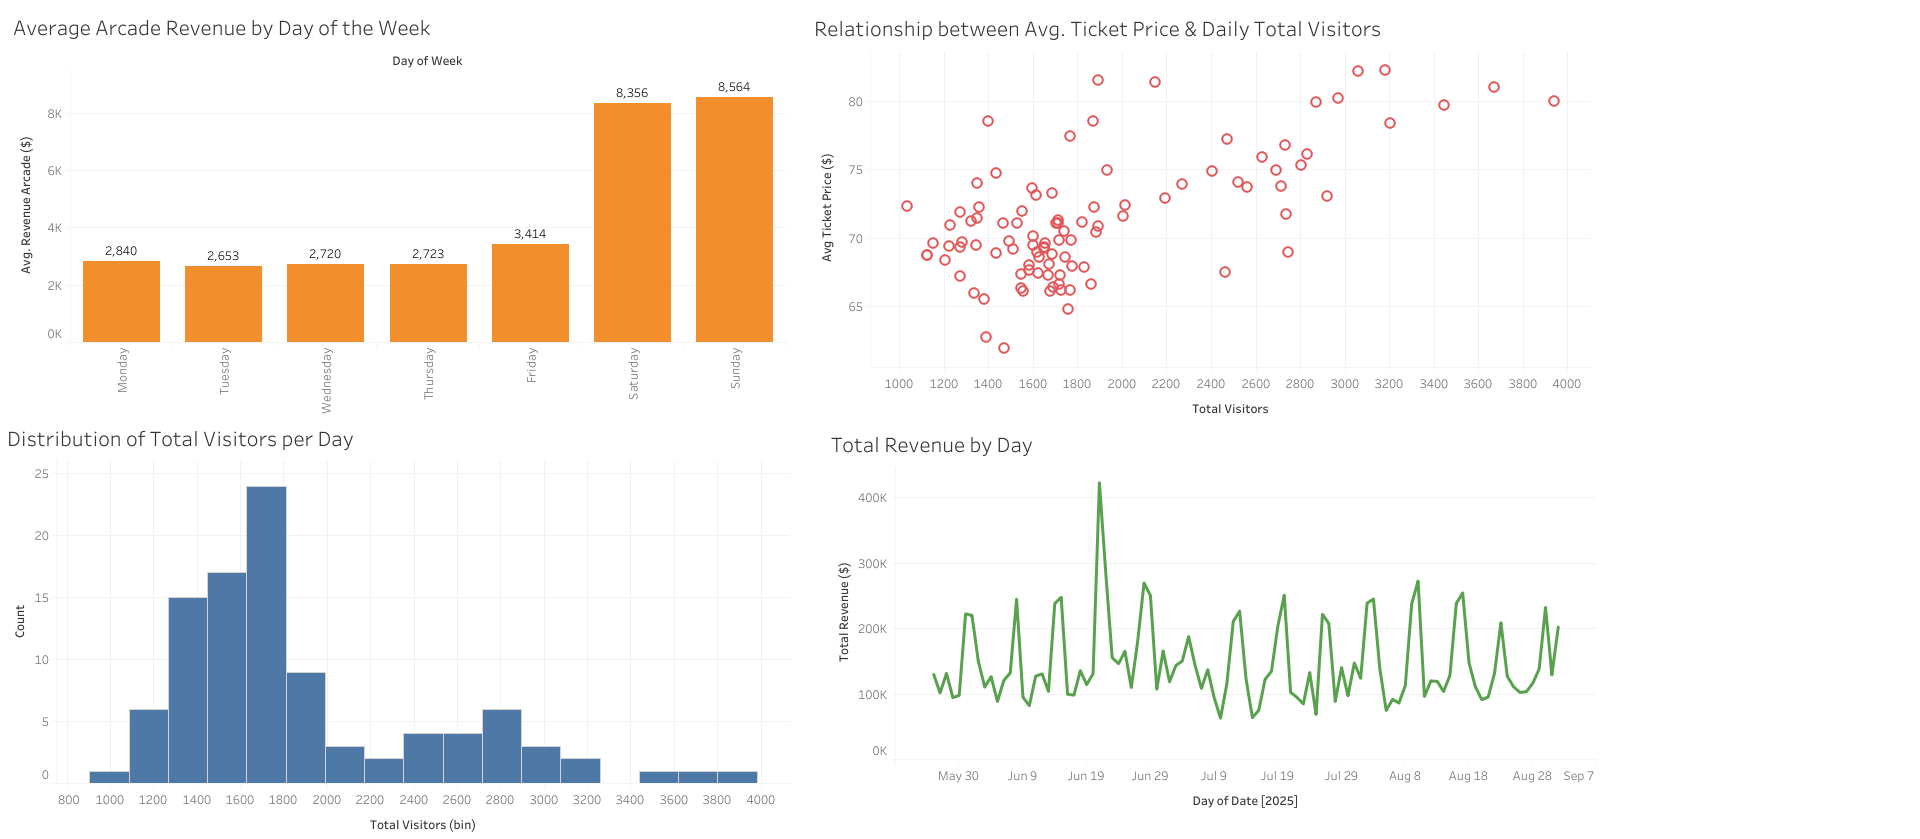

https://us-east-1.online.tableau.com/t/bdegouw-81c370a546/views/AD654Assignment4/Dashboard1

For my Tableau Dashboard, I built 4 unique visualizations, including a bar chart, histogram, scatterplot and timeseries line plot.

For the Bar Chart, I plotted the average arcade revenue by day of the week. I chose to do this to show the breakdown of how the day of the week influences the revenue of the arcade. To create this plot, I added the day of the week to the columns and the average arcade revenue to the rows. For the Histogram, I plotted the total visitors per day, binned by 181 visitors. I did this to see the distribution of number of daily visitors throughout the summer. To create this plot, I added the total visitors to the columns, and followed the bins suggested size of 181, and added the count to the rows. For the Scatterplot, I plotted the total vistors per day by the average ticket price. I did this to capture any relationship between the two variables, and get insight to the strength of the relationship between the two variables.To create this plot, I added the total visitors to the columns, and then added the average ticket price to the rows. For the Timeseries, I plotted the total revenue by each day that Lobsterland was open during the summer. I did this to see the flucations and trends of daily revenue on a daily level, and to gain insight into the peak days as well as the lower performing days. TO create this graph, I added the day/date to the columns, and then the total revenue by attribute to the rows.

This was a very valuable exercise for me as I had not used Tableau before. I did find myself refering to ChatGPT for some guidance on structuring the graphs and scaling them correctly in the published view. I did find Tableau less intuitive than using PowerBI, but am grateful to have had some experience practicing it. I did some brief research into the differences, and found out that Tableau offers more advanced visualization options - more reason to continue to practice!

